# **IS4487 Module 9 - Practice/Demo code**

This notebook is designed to help you follow along with the **Module 9 Lecture and Reading**, introducing you to segmentation through clustering.

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Use K-Means Clustering for Segmentation
- Plot the results

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_09_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Customer Segmentation
We will use a simple dataset using the following retail shopper characteristics

| Feature     | Description                                          | Type        |
| ------------ | ---------------------------------------------- | --------|
| CustomerID   | customer ID number                             | Numeric |
| Visits       | Number of visits in the last 2 years           | Numeric |
| Spending   | Total amount spent in the last 2 years           | Numeric |
| Annual income (k$)   | Annual income in thousands of dollars  | Numeric |
| Cluster      | Actual cluster the data came from              | Numeric |


There is no target variable!  You will be grouping the customers

# **ML model: K-Means Clustering**

K-Means is an **unsupervised learning** algorithm that groups data into **k** clusters by minimizing the distance between points and their cluster’s center (centroid).

### How it works?
It starts by randomly selecting k centroids, then iteratively assigns points to the nearest centroid and updates centroids until the solution stabilizes.

### Where is it used?
Unsupervised learning is often used in descriptive and diagnostic analytics. It is not considered as predictive analytics/modeling. Supervised learning requires labeled data (dataset where we know the target's true/actual values for some of the observations).

## **Step 1: Load libraries, create sample demo data**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse, Circle




Let us use the data in the URL below which contain 200 observations, that come from 3 real groups of customers that vary in Income, Spending and Visits. This data however has come overlap among clusters, as is often the case in the real world.

In [ ]:
URL = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/customer_data_clustering.csv"
df = pd.read_csv(URL)

df.head()

,CustomerID,Spending,Visits,Annual Income (k$),Cluster
0,1,472.559592,11,146.412320,1
1,2,126.716085,3,60.000000,0
2,3,125.226401,2,118.246353,0
3,4,327.610239,11,179.067057,2
4,5,673.452276,12,142.306284,1


## **Step 2: Prepare Data for Clustering**

Before applying k-means, we need to prepare the data.

Most clustering algorithms — especially K-Means and GMM — use a distance-based metric (typically Euclidean distance or Manhattan distance) to measure similarity between points. If your features are on very different scales, the ones with larger numeric ranges dominate the distance calculation (leading to biased clusters).

For the subset of features used for clustering, we will want to scale them all in a similar fashion. You can ***choose either normalization or standardization*** for this. Whether you use Min–Max (0–1) or StandardScaler (z-score) depends on the data’s distribution. MinMax is good for bounded features, Z-score is good for normally distributed features.

When we transform our data using MinMaxScaler (normalization) or StandardScaler (standardization), we use a method called `.fit_transform()` which first **fits** or learn the patterns (mean, stddev, min, max etc) from data, and then **transforms** or scales the data.

In [ ]:
# select a subset of features to use for clustering
X = df[['Annual Income (k$)', 'Spending', 'Visits']]

# Scale features by standardizing them
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Step 3: Fit K-means Model**

In this step, we will initialize the model and apply it.
The command to apply the model is `model.fit_predict()`. This does two things: **fit** and **predict**.

The **fit** step learns the patterns and association in data first. Then **predict** step will produce the output of the model - the group ID. In this case, we are NOT making a prediction; rather we are determining the hidden underlying grouping of observations.

In [ ]:
# Initialize the model - we ask for 3 clusters, and give it a random starting seed = 42
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and obtain the output of the model - group ID stored in column cluster.
df['Cluster_kmeans'] = kmeans.fit_predict(X_scaled)

## **Step 4: Visualize K-means Model**

In [ ]:
# View the groups produced in the output of k-means
df['Cluster_kmeans'].value_counts()

,count
Cluster_kmeans,
1,70
2,66
0,64


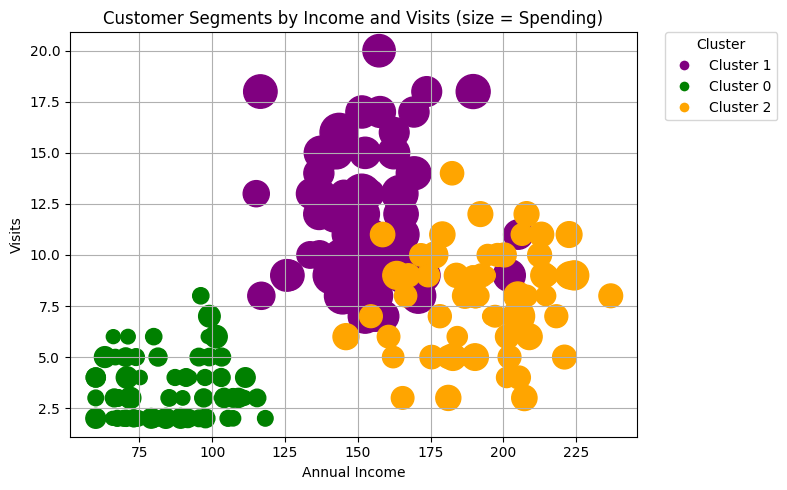

In [ ]:
from matplotlib.lines import Line2D

# choose colors to use for each cluster
colors = ['purple', 'green', 'orange']

# plot each cluster one by one
plt.figure(figsize=(8,5))
for i, cluster in enumerate(df['Cluster_kmeans'].unique()):
    subset = df[df['Cluster_kmeans'] == cluster]
    plt.scatter(subset['Annual Income (k$)'], subset['Visits'], s = subset['Spending'], color=colors[i], label=f'Cluster {cluster}')

plt.xlabel('Annual Income')
plt.ylabel('Visits')
plt.title('Customer Segments by Income and Visits (size = Spending)')

# --- Custom legend with uniform marker size ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}', markerfacecolor=colors[i], markersize=8) for i, cluster in enumerate(df['Cluster'].unique()) ]
plt.legend( handles=legend_elements, title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.grid(True)
plt.tight_layout()
plt.show()

What do you observe in the chart above?

### **Visualize Model Again with Centroids**

Let us replot the above chart, but this time we will draw the cluster spheres and their centroid.

Please note: While k-means tries to creates spherical clusters of similar size, the spheres will be drawn as ellipses because the scale of the variables on the two axes are very different in the raw data.

Dont worry about the code - this is just for demonstration.

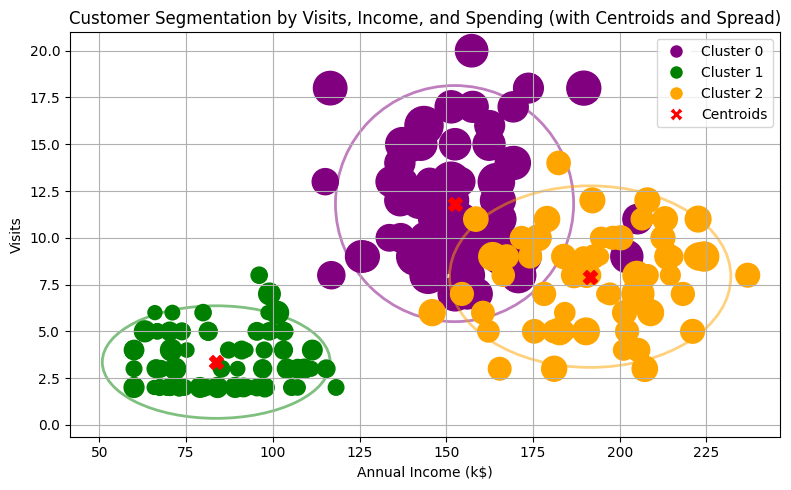

In [ ]:
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# Plot clusters in a chart of Visits (Y) vs Annual Income (X)
plt.figure(figsize=(8, 5))
# Get the current axes for adding patches
ax = plt.gca()

# Get the unique clusters
unique_clusters = df['Cluster_kmeans'].unique()
# choose colors to use for each cluster
colors = ['purple', 'green', 'orange']


# Plot data points with size representing spending
for i, cluster in enumerate(unique_clusters):
    subset = df[df['Cluster_kmeans'] == cluster]
    plt.scatter(subset['Annual Income (k$)'], subset['Visits'], s=subset['Spending'], label=f'Cluster {cluster}', color=colors[i])

    # Calculate the center and standard deviation for each cluster
    center_x = subset['Annual Income (k$)'].mean()
    center_y = subset['Visits'].mean()
    std_x = subset['Annual Income (k$)'].std()
    std_y = subset['Visits'].std()

    # Create an ellipse patch representing the spread (e.g., 2 standard deviations)
    # Angle is 0 because we are not rotating based on covariance
    ellipse = Ellipse((center_x, center_y), width=std_x * 4, height=std_y * 4,
                      edgecolor=colors[i], fc='None', lw=2, alpha=0.5)
    ax.add_patch(ellipse)

# Get the centroids from the fitted KMeans model
# We need to inverse transform them to the original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot centroids
# Note: Centroids are in the order of the clusters as they appear in unique_clusters if they were sorted,
# but since we are iterating through unique_clusters and using the index i, the colors will match.
plt.scatter(centroids[:, 0], centroids[:, 2], marker='X', s=100, color='red', label='Centroids')


# Create a custom legend with fixed marker size and matching colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}',
                          markerfacecolor=colors[i], markersize=10)
                   for i, cluster in enumerate(unique_clusters)]

# Add the centroid marker to the legend elements
legend_elements.append(Line2D([0], [0], marker='X', color='w', label='Centroids',
                              markerfacecolor='red', markersize=10))


plt.xlabel('Annual Income (k$)')
plt.ylabel('Visits')
plt.title('Customer Segmentation by Visits, Income, and Spending (with Centroids and Spread)')
plt.legend(handles=legend_elements)
plt.grid(True)
plt.tight_layout()
plt.show()

We show 3 clusters with very different centroids. However, as you will see the distributions of the data points contains some overlaps for cluster 0 and 2.

While K-Means ***assumes that data come from non-overlapping clusters***, if in reality data come from overlapping distributions (which is the case for the data that we used), we will see this sort of cluster result.

What K-Means does is place each data point into a single cluster - called **hard clustering**. It appears though that for some of the yellow and purple points that are in the intersection of cluster 2 and 0, a **soft clustering** such as GMM might be more appropriate.

# **ML model: Gaussian Mixture Models (GMM)**

Gaussian Mixture Models (GMM) are a probabilistic model for representing the presence of subpopulations within an overall population, without requiring that an observation must belong to a particular subpopulation. It allows data to probabilistically belong to multiple clusters, and by default, it ***assigns points to the cluster with maximum probability***.

Just as with kmean's `.fit_predict()` method, GMM also has a `.fit_predict()` method. By default, it will assign each observation to the cluster with the highest predicted probability.

Here's how to apply GMM using scikit-learn:



## **Step 5: Fit GMM model**

In [ ]:
# Initialize the GMM model - let's use 3 components (clusters) for comparison with K-Means
gmm = GaussianMixture(n_components=3, random_state=42)

# Fit the model to the scaled data and predict the cluster assignments
df['Cluster_GMM'] = gmm.fit_predict(X_scaled)

# obtain all 3 predicted probabilities
probabilities = gmm.predict_proba(X_scaled)

# Convert probabilities to a DataFrame to use .head()
probabilities_df = pd.DataFrame(probabilities, columns=[f'Cluster_{i}_Prob' for i in range(probabilities.shape[1])])
print("Cluster probabilities for the first 5 data points:")
display(probabilities_df.head(5))

# Display the count of observations in each GMM cluster
print("Count of observations per GMM cluster:")
display(df['Cluster_GMM'].value_counts())

Cluster probabilities for the first 5 data points:


,Cluster_0_Prob,Cluster_1_Prob,Cluster_2_Prob
0,9.996563e-01,2.120928e-19,3.437082e-04
1,6.419656e-12,1.000000e+00,1.599257e-11
2,3.985623e-06,9.998430e-01,1.530326e-04
3,2.800821e-02,6.468136e-14,9.719918e-01
4,1.000000e+00,4.662394e-42,4.330025e-10


Count of observations per GMM cluster:


,count
Cluster_GMM,
1,70
2,66
0,64


## **Step 6: Compare K-means and GMM clusters**

Analyze how the cluster assignments from K-Means and GMM differ. We can use a contingency table (also known as cross-tabulation), which maps two categorical variables.

For most part, the two clustering techniques agree, except in a small number of instances, very likely in the region of overlap between cluster 0 and 2. As seen above, GMM produces probabilities for belonging to each cluster for each data point.

In [ ]:
# Create a contingency table to compare K-Means and GMM cluster assignments
contingency_table = pd.crosstab(df['Cluster_kmeans'], df['Cluster_GMM'])
print("Contingency Table (K-Means vs GMM Clusters):")
display(contingency_table)

Contingency Table (K-Means vs GMM Clusters):


Cluster_GMM,0,1,2
Cluster_kmeans,,,
0,62,0,2
1,0,70,0
2,2,0,64


## **Step 7: Analyze cluster characteristics**
Clusters are identified by their ID/cluster number - but in order to understand what each cluster represents, we will need to perform some descriptive analysis on the features used for clustering.

Calculate and display descriptive statistics (like mean or median income, spending, and visits) for each of the GMM clusters to understand their characteristics.



In [ ]:
# Group by GMM cluster and calculate the mean for specified columns
gmm_cluster_characteristics = df.groupby('Cluster_GMM')[['Annual Income (k$)', 'Spending', 'Visits']].mean()

# Display the results
print("Mean characteristics for each GMM Cluster:")
display(gmm_cluster_characteristics)

Mean characteristics for each GMM Cluster:


,Annual Income (k$),Spending,Visits
Cluster_GMM,,,
0,150.865659,534.750470,11.750000
1,83.690547,150.206852,3.357143
2,192.983781,284.665404,8.000000


We can see below that they are different in all three features - Visit, Spending and Annual Income. We may label the groups as:
- cluster 1: low earners, low spenders, infrequent visitors
- cluster 2: high earners, moderate spenders, moderate visits
- cluster 3: medium earners, high spenders, frequent visitors

